# Pima Indians Diabetes Random Forest 분류

## 개요
- Random Forest Classifier를 활용한 당뇨병 예측
- GridSearchCV로 하이퍼파라미터 최적화
- 피처 중요도 분석 및 시각화

## Random Forest 특징
- 스케일링 불필요 (거리 기반 아님)
- 자체 피처 중요도 산출 (Gini Importance)
- 과적합 방지 (앙상블 효과)

## 주요 단계
1. 데이터 로드 및 분리
2. GridSearchCV 하이퍼파라미터 탐색
3. 최적 모델 평가
4. 피처 중요도 분석

## 라이브러리 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [5]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.astype('category').cat.codes # Convert categorical strings to numerical codes

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
0    500
1    268
Name: count, dtype: int64


**데이터 샘플 확인**

In [6]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.

**학습/테스트 데이터 분리**

In [7]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")
print(f"\nTest 클래스 분포:\n{y_test.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
0    400
1    214
Name: count, dtype: int64

Test 클래스 분포:
0    100
1     54
Name: count, dtype: int64


## 2. Random Forest Classifier

**Random Forest 특징**
- 스케일링 불필요: 거리 기반이 아닌 트리 기반
- 피처 중요도: Gini Importance 자동 계산
- 과적합 방지: 다수의 트리 앙상블
- 비선형 관계 학습 가능

**하이퍼파라미터**
- n_estimators: 트리 개수
- max_depth: 트리 최대 깊이 (과적합 방지)
- min_samples_split: 노드 분할 최소 샘플
- min_samples_leaf: 리프 노드 최소 샘플

**모델 및 하이퍼파라미터 그리드 설정**

In [8]:
# Random Forest 모델
rf_clf = RandomForestClassifier(random_state=42)

# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Random Forest Classifier 생성")
print(f"\n파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

Random Forest Classifier 생성

파라미터 그리드:
  n_estimators: [100, 200]
  max_depth: [None, 10, 20]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]

총 조합 수: 24개


## 3. GridSearchCV 하이퍼파라미터 탐색

**GridSearchCV 설정**
- cv: StratifiedKFold(5) - 클래스 비율 유지
- scoring: accuracy
- n_jobs=-1: 모든 CPU 코어 사용

In [9]:
# GridSearchCV
print("Tuning RandomForest Classifier...")
print("(교차검증 수행 중...)\n")

grid_clf = GridSearchCV(
    rf_clf,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train, y_train)
print("\nGridSearchCV 완료!")

Tuning RandomForest Classifier...
(교차검증 수행 중...)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [10]:
# 최적 모델 추출
best_clf = grid_clf.best_estimator_

print("[최적화 결과]")
print(f"Best Accuracy (Train CV): {grid_clf.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_clf.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best Accuracy (Train CV): 0.7801

Best Parameters:
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 100


**GridSearchCV 상위 결과**

In [11]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_clf.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators param_max_depth  param_min_samples_split  param_min_samples_leaf  mean_test_score  std_test_score
                100            None                        2                       2         0.780141        0.032441
                100              20                        2                       2         0.780141        0.032441
                100              10                        2                       1         0.776889        0.042189
                200              10                        2                       1         0.776889        0.043424
                100              10                        2                       2         0.775263        0.027343


## 5. 테스트 데이터 평가

**예측 및 성능 평가**

In [12]:
# 테스트 데이터 예측
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7403

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



**Confusion Matrix 시각화 (선택사항)**

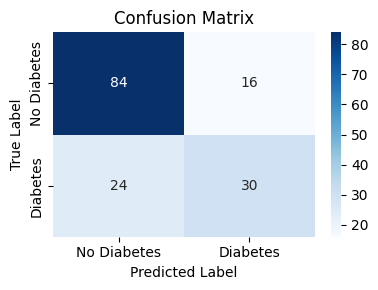

In [18]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**Gini Importance**
- 각 피처가 불순도를 얼마나 감소시키는지 측정
- 값이 클수록 중요한 피처
- Random Forest 자체 계산 (별도 분석 불필요)

In [14]:
# 피처 중요도 추출
importances = best_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
Feature  Importance
   plas    0.297729
   mass    0.167266
   pedi    0.120570
    age    0.115971
   pres    0.083313
   preg    0.077996
   insu    0.071926
   skin    0.065228


**피처 중요도 시각화**

/tmp/ipython-input-1131470680.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


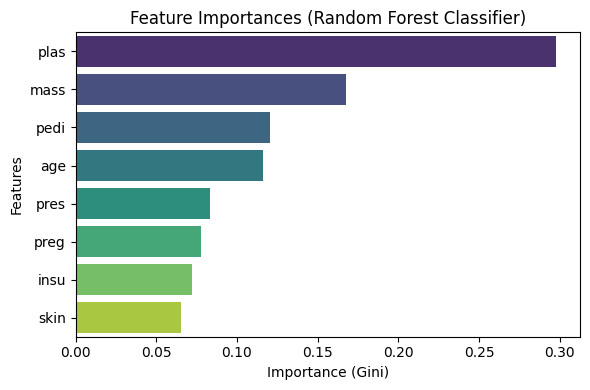

In [19]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (Random Forest Classifier)")
plt.xlabel("Importance (Gini)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 7. 상위 피처만 사용한 모델 비교

**상위 5개 피처로 재학습**

In [16]:
# 상위 5개 피처 선택
top_5_features = feature_names[indices[:5]]
print(f"상위 5개 피처: {list(top_5_features)}")

# 상위 피처만으로 학습
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

rf_top5 = RandomForestClassifier(**grid_clf.best_params_, random_state=42)
rf_top5.fit(X_train_top5, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5)
accuracy_top5 = accuracy_score(y_test, y_pred_top5)

# 비교
print("\n성능 비교:")
print(f"모든 피처 (8개): Accuracy = {test_accuracy:.4f}")
print(f"상위 5개 피처: Accuracy = {accuracy_top5:.4f}")
print(f"\n정확도 차이: {test_accuracy - accuracy_top5:+.4f}")

상위 5개 피처: ['plas', 'mass', 'pedi', 'age', 'pres']

성능 비교:
모든 피처 (8개): Accuracy = 0.7403
상위 5개 피처: Accuracy = 0.7792

정확도 차이: -0.0390
